<a href="https://colab.research.google.com/github/AdamClarkStandke/TransDiffTemp/blob/main/Chapter7_InstructionFineTuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7 and Appendix: Fine-tuning to follow instructions

This notebook implements chapter 7, Appendix D and Appendix E of the book [Build A Large Language Model From Scrath by Sebastian Raschka](https://github.com/rasbt/LLMs-from-scratch). Chapter 7 takes the pretrained weights of gpt2 and fine-tunes it on an instruction set. This is the main step behind developing LLMs for chatbots, personal assistants and AI agents. This process is broken down into three stages:
*   **Stage 1: Preparing the dataset**
*   **Stage 2: Fine-Tuning the Pretrained LLM**
*   **Stage 3: Evaluating the LLM**




# Stage 1: Preparing the Dataset

Preparing the Dataset for fine-tuning a model using PyTorch consists of 1) downloading the dataset and formatting it; 2)  batching the dataset; and 3) creating data loaders. At first I tried using the [LIMA](https://huggingface.co/buckets/DexHeim/lima-bucket) dataset which was created for the paper [LIMA:Less Is More for Alignment](https://arxiv.org/pdf/2305.11206). It consists of 1,000 carefully curated prompts and responses. The paper used a **65 billion** parameter [LLaMa model](https://en.wikipedia.org/wiki/Llama_(language_model)) to finetune on the 1,000 prompts and respons and got amazing results!! (adding evidence to the [Superficial Alignment Hypothesis](https://arxiv.org/pdf/2410.03717) which is still an open question). The largest gpt2 model released was gpt2-xl has over 1 billion parameters and I intially used this model for fine-tuning on the LIMA dataset. However, with only 1,000 examples the model was overfitting after the second epoch!!!

I then turned my attention to the [Stanford Alpaca](https://github.com/tatsu-lab/stanford_alpaca) dataset consisting of 52K instruction based prompts. It consists of an instruction and a response and sometimes an input. After filtering out the prompts with inputs the dataset consisted of 31,323 examples. These were split into 90% training, 5% validation and 5% for later testing/evaluation. This was the dataset I was able to use to fine-tune the gpt2-large model of 774M million parameters for 3 epochs and not overfit!

## Dataset Downloading and Formatting

### Stanford Alpaca

In [1]:
# Helper function to download and load the Alpaca dataset
import json
import os
import requests
def download_and_load_file(file_path, url):
  if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
      file.write(text_data)
  with open(file_path, "r", encoding="utf-8") as file:
    data = json.load(file)
  return data

In [2]:
# file path to dump json file
file_path = "alpaca_data.json"
# url of github repo containing Alpaca data
url = (
    "https://raw.githubusercontent.com/tatsu-lab/stanford_alpaca/refs/heads/main/alpaca_data.json"
)
# calling above function to download and load data
data_one = download_and_load_file(file_path, url)
# printing number of examples
print("Number of entries:", len(data_one))

Number of entries: 52002


In [3]:
#Function to filer out prompts that contain an input
#so data only contains instructions and responses
def filter_alpacha(data_one):
  s = []
  for i in data_one:
    if i['input'] =='':
      s.append(i)
  return s
fil_data = filter_alpacha(data_one)

In [4]:
#Printing out filtered dataset
len(fil_data)

31323

In [5]:
# Printing out example format of Alpaca data
fil_data[0]

{'instruction': 'Give three tips for staying healthy.',
 'input': '',
 'output': '1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. \n2. Exercise regularly to keep your body active and strong. \n3. Get enough sleep and maintain a consistent sleep schedule.'}

In [6]:
#Printing out instruction and response found in str format
print(f"Instruction: {fil_data[0]['instruction']}")
print(f"Output: {fil_data[0]['output']}")

Instruction: Give three tips for staying healthy.
Output: 1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. 
2. Exercise regularly to keep your body active and strong. 
3. Get enough sleep and maintain a consistent sleep schedule.


In [7]:
# Spliting data into training, testing and validation
train_portion = int(len(fil_data) * 0.90)
test_portion = int(len(fil_data) * 0.05)
val_portion = len(fil_data) - train_portion - test_portion

train_data_al = fil_data[:train_portion]
test_data_al = fil_data[train_portion:train_portion + test_portion]
val_data_al = fil_data[train_portion+test_portion:]

### LIMA

In [8]:
# !pip install jsonlines

In [9]:
# Download this bucket to a local folder if it does not exist
# !hf sync hf://buckets/DexHeim/lima-bucket ./local

In [10]:
# Downloading dataset of LIMA instructions
# import jsonlines
# import json
# file_path = "local/train.jsonl"

# def download_loadfile(file):
#   data = []
#   with open(file, 'r') as f:
#     for line in f:
#         data.append(json.loads(line.strip()))
#   return data

# data_two = download_loadfile(file_path)

In [11]:
# len(data_two)

In [12]:
# data_two[0]

In [13]:
# # sample of instuctions in dataset
# print(f"Instruction: {data_two[0]['conversations'][0]}")
# print(f"Output: {data_two[0]['conversations'][1]}")

In [14]:
# partitioning the dataset
# train_portion = int(len(data_two) * 0.95)
# test_portion = int(len(data_two) * 0.0)
# val_portion = len(data_two) - train_portion - test_portion

# train_data = data_two[:train_portion]
# test_data = data_two[train_portion:train_portion + test_portion]
# val_data = data_two[train_portion+test_portion:]

### Alpaca Prompt Style

Below are two functions to format the instruction datasets into prompt templates for fine-tuning i.e., from JSON dictionary format into prompts. I decided to go with the Alpaca prompt style rather than Microsoft's Phi-3 prompt style since I am using the Alpaca dataset. The Alpaca style uses a structured format with defined sections for instruction, input and response while the Phi-3 style has a simpler format with designated **<|user|>** and **<|assistant|> **tokens.



In [15]:
#Prompt format for LIMA dataset
def format_input(entry):
  instruction_text = (
      f"Below is an instruction that describes a task."
      f"Write a response that appropriately completes the request."
      f"\n\n### Instruction:\n{entry['conversations'][0]}"
  )
  return instruction_text

#Prompt format for Alpaca dataset
def format_input_alpaca(entry):
  instruction_text = (
      f"Below is an instruction that describes a task."
      f"Write a response that appropriately completes the request."
      f"\n\n### Instruction:\n{entry['instruction']}"
  )
  return instruction_text

## Batching the Dataset

In [16]:
import torch
from torch.utils.data import Dataset, DataLoader
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

class InstructionDataset(Dataset):
  def __init__(self, data, data_al, tokenizer):
    super().__init__()
    self.data = data
    self.data_al = data_al
    self.encoded_texts = []
    # for entry in data:
    #   instruction = format_input(entry)
    #   response_text = f"\n\n### Response:\n{entry['conversations'][1]}"
    #   full_text = instruction + response_text
    #   self.encoded_texts.append(tokenizer.encode(full_text))
    for entry in data_al:
      instruction = format_input_alpaca(entry)
      response_text = f"\n\n### Response:\n{entry['output']}"
      full_text = instruction + response_text
      self.encoded_texts.append(tokenizer.encode(full_text))

  def __getitem__(self, index):
    return self.encoded_texts[index]

  def __len__(self):
    # return len(self.data) + len(self.data_al)
    return len(self.data_al)

In [17]:
def custom_collate_fn(batch,
                      pad_token_id = 50256,
                      ignore_index = -100,
                      allowed_max_length = 1024,
                      device="cpu",
                      input_mask = False
                      ):
  batch_max_length = max(len(item)+1 for item in batch)
  inputs_ls, targets_ls = [], []
  for item in batch:
    new_item = item.copy()
    new_item += [pad_token_id]
    padded = (new_item+[pad_token_id]*(batch_max_length - len(new_item)))
    inputs = torch.tensor(padded[:-1])
    targets = torch.tensor(padded[1:])

    mask = targets == pad_token_id
    indices = torch.nonzero(mask).squeeze()
    if indices.numel() > 1:
      targets[indices[1:]] = ignore_index

    if allowed_max_length is not None:
      inputs = inputs[:allowed_max_length]
      targets = targets[:allowed_max_length]

    inputs_ls.append(inputs)
    targets_ls.append(targets)

  inputs_tensor = torch.stack(inputs_ls).to(device)
  targets_tensor = torch.stack(targets_ls).to(device)

  return inputs_tensor, targets_tensor

## Creating Dataloaders

In [18]:
from functools import partial

if torch.cuda.is_available():
  device = torch.device("cuda")
else:
  device = torch.device("cpu")

customized_collate_fn = partial(
    custom_collate_fn,
    device=device
)

In [19]:
num_workers = 0
batch_size = 5
torch.manual_seed(123)

train_dataset = InstructionDataset(train_data_al, train_data_al, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle = True,
    drop_last = True,
    num_workers = num_workers
)

val_dataset = InstructionDataset(val_data_al, val_data_al, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle = False,
    drop_last = False,
    num_workers = num_workers
)

test_dataset = InstructionDataset(test_data_al, test_data_al, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle = False,
    drop_last = False,
    num_workers = num_workers
)

In [20]:
print("Train loader:")
count=0
for inputs, targets in train_loader:
  print(inputs.shape, targets.shape)
  count+=1
  if count == 10:
    break

Train loader:
torch.Size([5, 125]) torch.Size([5, 125])
torch.Size([5, 339]) torch.Size([5, 339])
torch.Size([5, 126]) torch.Size([5, 126])
torch.Size([5, 203]) torch.Size([5, 203])
torch.Size([5, 146]) torch.Size([5, 146])
torch.Size([5, 268]) torch.Size([5, 268])
torch.Size([5, 210]) torch.Size([5, 210])
torch.Size([5, 203]) torch.Size([5, 203])
torch.Size([5, 191]) torch.Size([5, 191])
torch.Size([5, 141]) torch.Size([5, 141])


# Stage 2: Finetuning the LLM

## Loading a pretrained LLM

In [21]:
# downloading helper functions and GPT-2 model
import os
import requests
from huggingface_hub import download_bucket_files
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch07/01_main-chapter-code/previous_chapters.py"
!touch "/content/previous_chapters.py"
file_path = "/content/previous_chapters.py"
response = requests.get(url, timeout=100)
response.raise_for_status()
text_data = response.text
with open(file_path, "w", encoding="utf-8") as file:
  file.write(text_data)

In [22]:
from previous_chapters import GPTModel, generate, token_ids_to_text, text_to_token_ids

In [23]:
BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

# different model configuations of GPT-2
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# creating copy of our config file
model_name = "gpt2-large (774M)"

BASE_CONFIG.update(model_configs[model_name])

# downloading pretrained weights
'''
different gpt2 model sizes:
gpt2-small-124M.pth
gpt2-medium-355M.pth
gpt2-large-774M.pth
gpt2-xl-1558M.pth
'''
file_name = "gpt2-large-774M.pth"

download_bucket_files(
    bucket_id = "DexHeim/gpt2-from-scratch-pytorch-bucket",
    files = [(f"{file_name}", f'./{file_name}')]
)


In [24]:
# loading pretrained weights into our model
from safetensors.torch import load_file
gpt = GPTModel(BASE_CONFIG)
gpt.load_state_dict(torch.load(file_name, weights_only=True))

<All keys matched successfully>

## Appendix E: Parameter-Efficient Fine-Tuning with LoRA

In [25]:
from previous_chapters import calc_loss_loader, train_model_simple

In [26]:
for param in gpt.parameters():
  param.requires_grad = False
total_params = sum(p.numel() for p in gpt.parameters() if p.requires_grad)
print(f"Total trainable parameters after: {total_params:,}")

Total trainable parameters after: 0


In [27]:
import math

class LoRALayer(torch.nn.Module):
  def __init__(self, in_dim, out_dim, rank, alpha):
    super().__init__()
    self.A  = torch.nn.Parameter(torch.empty(in_dim, rank))
    torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
    self.B = torch.nn.Parameter(torch.zeros(rank, out_dim))
    self.alpha = alpha
    self.rank = rank

  def forward(self, x):
    x = (self.alpha/self.rank)*(x @ self.A @ self.B)
    return x

class LinearWithLoRA(torch.nn.Module):
  def __init__(self, linear, rank, alpha):
    super().__init__()
    self.linear = linear
    self.lora = LoRALayer(
        linear.in_features, linear.out_features, rank, alpha
    )

  def forward(self, x):
    return self.linear(x) +self.lora(x)

In [28]:
# code from https://lightning.ai/lightning-ai/templates/code-lora-from-scratch?section=featured

from functools import partial

# default hyperparameter choices
lora_r = 16
lora_alpha = 16
lora_dropout = 0.05
lora_query = True
lora_key = True
lora_value = True
lora_projection = True
lora_mlp = True
lora_head = False

layers = []

assign_lora = partial(LinearWithLoRA, rank=lora_r, alpha=lora_alpha)

for layer in gpt.trf_blocks:
    if lora_query:
        layer.att.W_query = assign_lora(layer.att.W_query)
    if lora_key:
        layer.att.W_key = assign_lora(layer.att.W_key)
    if lora_value:
        layer.att.W_value = assign_lora(layer.att.W_value)
    if lora_projection:
        layer.att.out_proj = assign_lora(layer.att.out_proj)
    if lora_mlp:
        layer.ff.layers[0] = assign_lora(layer.ff.layers[0])
        layer.ff.layers[2] = assign_lora(layer.ff.layers[2])
if lora_head:
    model.pre_classifier = assign_lora(model.pre_classifier)
    model.classifier = assign_lora(model.classifier)

In [29]:
total_params = sum(p.numel() for p in gpt.parameters() if p.requires_grad)
print(f"Total trainable LoRA parameters: {total_params:,}")

Total trainable LoRA parameters: 13,271,040


In [30]:
print(gpt)

GPTModel(
  (tok_emb): Embedding(50257, 1280)
  (pos_emb): Embedding(1024, 1280)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): LinearWithLoRA(
          (linear): Linear(in_features=1280, out_features=1280, bias=True)
          (lora): LoRALayer()
        )
        (W_key): LinearWithLoRA(
          (linear): Linear(in_features=1280, out_features=1280, bias=True)
          (lora): LoRALayer()
        )
        (W_value): LinearWithLoRA(
          (linear): Linear(in_features=1280, out_features=1280, bias=True)
          (lora): LoRALayer()
        )
        (out_proj): LinearWithLoRA(
          (linear): Linear(in_features=1280, out_features=1280, bias=True)
          (lora): LoRALayer()
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): LinearWithLoRA(
            (linear): Linear(in_features=1280

## Appendix D: Training Loop with LR warmup with Cosine decay and Gradient Clipping

In [32]:
from previous_chapters import evaluate_model, generate_and_print_sample, calc_loss_batch
import time
def train_model(model, train_loader, val_loader, optimizer, device,
                n_epochs, eval_freq, eval_iter, start_context, tokenizer,
                warmup_steps, initial_lr=3e-05, min_lr=1e-6):
  train_losses, val_losses, track_tokens_seen, track_lrs = [], [], [], []
  tokens_seen, global_step = 0, -1

  peak_lr = optimizer.param_groups[0]["lr"]
  total_training_steps = len(train_loader) * n_epochs
  lr_increment = (peak_lr-initial_lr)/warmup_steps

  for epoch in range(n_epochs):
    model.train()
    for input_batch, target_batch in train_loader:
      optimizer.zero_grad()
      global_step += 1
      if global_step < warmup_steps:
        lr = initial_lr + global_step * lr_increment
      else:
        progress = ((global_step-warmup_steps)/
                    (total_training_steps - warmup_steps))
        lr = min_lr + (peak_lr - min_lr) * 0.5 * (
           1 + math.cos(math.pi * progress))

      for param_group in optimizer.param_groups:
        param_group['lr'] = lr
      track_lrs.append(lr)
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      loss.backward()

      if global_step >= warmup_steps:
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )

      optimizer.step()
      tokens_seen += input_batch.numel()

      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model(
            model, train_loader, val_loader,
            device, eval_iter
        )
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f"Ep {epoch+1} (Iter {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
        )

    generate_and_print_sample(
        model, tokenizer, device, start_context
    )
  return train_losses, val_losses, track_tokens_seen, track_lrs

In [33]:
if torch.cuda.is_available():
  device = torch.device("cuda")
else:
  device = torch.device("cpu")
gpt.to(device)
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(gpt.parameters(), weight_decay=0.1)
num_epochs = 3
warmup_steps = int(0.2 * (len(train_loader) * num_epochs)) # 20% warmup
train_losses, val_losses, tokens_seen, lrs = train_model(
    gpt, train_loader, val_loader, optimizer, device,
    n_epochs=num_epochs, eval_freq=1000, eval_iter=2,
    start_context=format_input_alpaca(val_data_al[0]), tokenizer=tokenizer,
    warmup_steps=warmup_steps, initial_lr=1e-4, min_lr=1e-5
)

end_time = time.time()
execution_time_min = (end_time - start_time) / 60
print(f"Training completed in {execution_time_min:.2f} minutes.")

Ep 1 (Iter 000000): Train loss 2.458, Val loss 2.807
Ep 1 (Iter 001000): Train loss 1.356, Val loss 1.186
Ep 1 (Iter 002000): Train loss 1.301, Val loss 1.212
Ep 1 (Iter 003000): Train loss 1.639, Val loss 1.459
Ep 1 (Iter 004000): Train loss 1.216, Val loss 1.252
Ep 1 (Iter 005000): Train loss 1.399, Val loss 1.253
Below is an instruction that describes a task.Write a response that appropriately completes the request.  ### Instruction: Describe an organised crime syndicate.  ### Response: An organised crime syndicate is a group of criminals who have a common goal and are able to coordinate their activities. They are often involved in criminal activities such as drug trafficking, extortion, and money laundering. Organised crime
Ep 2 (Iter 006000): Train loss 1.036, Val loss 1.252
Ep 2 (Iter 007000): Train loss 1.428, Val loss 1.265
Ep 2 (Iter 008000): Train loss 1.119, Val loss 1.247
Ep 2 (Iter 009000): Train loss 1.133, Val loss 1.226
Ep 2 (Iter 010000): Train loss 1.236, Val loss 1.2

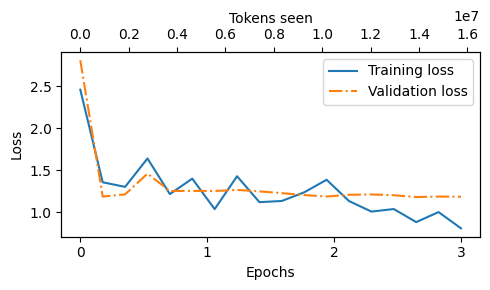

In [34]:
from previous_chapters import plot_losses
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

# Stage 3: Evaluating the LLM